# DDPM — Denoising Diffusion Probabilistic Models (from scratch)

Implementation based on the original paper: [Ho et al., 2020](https://arxiv.org/abs/2006.11239)

## Core Idea

Diffusion models work in two phases:

1. **Forward process** `q(x_t | x_{t-1})`: gradually add Gaussian noise to a real image over `T` steps until it becomes pure noise.
2. **Reverse process** `p_θ(x_{t-1} | x_t)`: train a neural network to predict and remove the noise, step by step, reconstructing the image.

At inference time, we start from pure noise and run the reverse process to generate a new image.

## Contents
1. Setup & Imports
2. Noise Schedule (Beta Schedule)
3. Forward Process
4. U-Net (the denoising network)
5. Training Loop
6. Sampling (image generation)
7. Visualisation

## DDPM — Full Flow Diagram

```mermaid
flowchart TB
    subgraph TRAIN["Training"]
        direction TB
        A["x₀\nclean image\nfrom dataset"]
        B["Sample timestep t\nt ~ Uniform(1, T)"]
        C["Sample noise\nε ~ N(0, I)"]
        D["Forward Process q\nx_t = √ᾱ_t · x₀ + √(1-ᾱ_t) · ε\none-shot corruption"]
        E["U-Net\nε_θ(x_t, t)"]
        F["MSE Loss\n‖ε − ε_θ(x_t, t)‖²"]
        G["Backpropagation\nupdate weights"]

        A --> D
        B --> D
        C --> D
        D --> E
        E --> F
        F --> G
    end

    subgraph SCHEDULE["Noise Schedule (pre-computed)"]
        direction LR
        S1["β₁, β₂, ..., β_T\nlinear schedule"]
        S2["ᾱ_t = ∏ (1 − βₛ)\ncumulative product"]
        S1 --> S2
    end

    subgraph SAMPLE["Inference (Sampling)"]
        direction TB
        P1["x_T\npure Gaussian noise\nx_T ~ N(0, I)"]
        P2["Reverse step\nx_{t-1} = (1/√α_t)(x_t − (1−α_t)/√(1−ᾱ_t) · ε_θ) + √β_t · z"]
        P3{"t = 0?"}
        P4["x_T-1, x_T-2, ...\nrepeat T times"]
        P5["x₀\ngenerated image"]

        P1 --> P2
        P2 --> P3
        P3 -- No --> P4
        P4 --> P2
        P3 -- Yes --> P5
    end

    SCHEDULE --> TRAIN
    SCHEDULE --> SAMPLE
    TRAIN -. "trained weights\nε_θ" .-> SAMPLE
```

## 1. Setup & Imports

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
torch.manual_seed(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cpu


In [3]:
# Hyperparameters
IMG_SIZE    = 28       # MNIST image size
CHANNELS    = 1        # grayscale
BATCH_SIZE  = 128
EPOCHS      = 10
LR          = 1e-3
T           = 1000     # number of diffusion timesteps

In [4]:
# MNIST dataset — pixel values normalised to [-1, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

print(f"Training samples: {len(train_dataset)}")

100.0%
100.0%
100.0%
100.0%

Training samples: 60000


## 2. Noise Schedule (Beta Schedule)

The forward process is controlled by a variance schedule `β_1, ..., β_T`.

At each step `t`, a small amount of Gaussian noise is added:

$$q(x_t | x_{t-1}) = \mathcal{N}(x_t; \sqrt{1 - \beta_t}\, x_{t-1},\; \beta_t \mathbf{I})$$

**Key insight — the reparameterisation trick:**

We don't need to apply noise step by step. We can jump directly to any timestep `t` in one shot:

$$q(x_t | x_0) = \mathcal{N}(x_t;\; \sqrt{\bar{\alpha}_t}\, x_0,\; (1 - \bar{\alpha}_t)\mathbf{I})$$

where $\bar{\alpha}_t = \prod_{s=1}^{t}(1 - \beta_s)$. This is what makes training efficient.

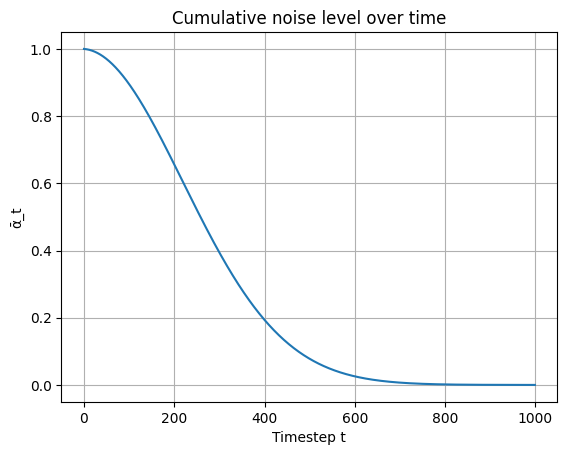

In [5]:
def linear_beta_schedule(timesteps: int) -> torch.Tensor:
    """
    Linear schedule from Ho et al. (2020).
    beta grows linearly from beta_start to beta_end over T steps.
    """
    beta_start = 1e-4
    beta_end   = 0.02
    return torch.linspace(beta_start, beta_end, timesteps)


# Pre-compute all quantities we'll need during training
betas      = linear_beta_schedule(T)                      # β_t
alphas     = 1.0 - betas                                  # α_t = 1 - β_t
alpha_bars = torch.cumprod(alphas, dim=0)                 # ᾱ_t = ∏ α_s

# Move to device
betas      = betas.to(DEVICE)
alphas     = alphas.to(DEVICE)
alpha_bars = alpha_bars.to(DEVICE)

# Visualise how ᾱ_t decays — at t=T it should be ≈ 0 (pure noise)
plt.plot(alpha_bars.cpu())
plt.xlabel("Timestep t")
plt.ylabel("ᾱ_t")
plt.title("Cumulative noise level over time")
plt.grid(True)
plt.show()

## 3. Forward Process

Using the reparameterisation trick, we can corrupt `x_0` directly to any timestep `t`:

$$x_t = \sqrt{\bar{\alpha}_t}\, x_0 + \sqrt{1 - \bar{\alpha}_t}\, \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)$$

This is the only thing we need from the forward process during training.

In [ ]:
def q_sample(x0: torch.Tensor, t: torch.Tensor, noise: torch.Tensor = None) -> torch.Tensor:
    """
    Forward process: corrupt x0 to timestep t in one step.
    
    x_t = sqrt(ᾱ_t) * x0  +  sqrt(1 - ᾱ_t) * ε
    
    Args:
        x0:    clean images,          shape (B, C, H, W)
        t:     timestep per image,    shape (B,)
        noise: optional pre-sampled noise (useful for debugging)
    """
    if noise is None:
        noise = torch.randn_like(x0)

    # Extract ᾱ_t for each image in the batch and reshape for broadcasting
    ab_t = alpha_bars[t].view(-1, 1, 1, 1)   # (B, 1, 1, 1)

    return torch.sqrt(ab_t) * x0 + torch.sqrt(1 - ab_t) * noise


# --- Visualise the forward process ---
sample_img = train_dataset[0][0].unsqueeze(0).to(DEVICE)   # (1, 1, 28, 28)
timesteps_to_show = [0, 100, 250, 500, 750, 999]

fig, axes = plt.subplots(1, len(timesteps_to_show), figsize=(12, 2))
for ax, t_val in zip(axes, timesteps_to_show):
    t_tensor = torch.tensor([t_val], device=DEVICE)
    noisy = q_sample(sample_img, t_tensor)
    ax.imshow(noisy.squeeze().cpu(), cmap="gray")
    ax.set_title(f"t={t_val}")
    ax.axis("off")

plt.suptitle("Forward process — adding noise progressively")
plt.tight_layout()
plt.show()

## 4. U-Net — The Denoising Network

The network receives a noisy image `x_t` and a timestep `t`, and predicts the noise `ε` that was added.

Architecture:
- **Encoder**: two downsampling blocks (Conv + GroupNorm + SiLU)
- **Bottleneck**: middle block
- **Decoder**: two upsampling blocks with skip connections from the encoder
- **Time embedding**: sinusoidal embedding of `t` injected into each block so the network knows "how noisy" the input is

This is a simplified U-Net — the original paper uses attention and residual blocks, but this is enough to understand the mechanics.

In [ ]:
class SinusoidalTimeEmbedding(nn.Module):
    """
    Encode a scalar timestep t into a vector of dimension `dim`.
    Uses sine/cosine at different frequencies (same idea as Transformer positional encoding).
    This lets the network distinguish between different noise levels.
    """
    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        # t shape: (B,)
        half = self.dim // 2
        freqs = torch.exp(
            -torch.arange(half, device=t.device) * (torch.log(torch.tensor(10000.0)) / (half - 1))
        )
        args = t[:, None].float() * freqs[None, :]   # (B, half)
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)  # (B, dim)


class ConvBlock(nn.Module):
    """Conv -> GroupNorm -> SiLU, with time embedding injected via addition."""
    def __init__(self, in_ch: int, out_ch: int, time_dim: int):
        super().__init__()
        self.conv   = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm   = nn.GroupNorm(8, out_ch)
        self.act    = nn.SiLU()
        self.time_proj = nn.Linear(time_dim, out_ch)  # project time embedding to channel dim

    def forward(self, x: torch.Tensor, t_emb: torch.Tensor) -> torch.Tensor:
        h = self.norm(self.conv(x))
        # Add time embedding (broadcast over spatial dims)
        h = h + self.time_proj(t_emb)[:, :, None, None]
        return self.act(h)


class SimpleUNet(nn.Module):
    """
    Minimal U-Net for noise prediction.
    Input : (B, 1, 28, 28) noisy image + timestep t
    Output: (B, 1, 28, 28) predicted noise
    """
    def __init__(self, in_channels: int = 1, base_channels: int = 64, time_dim: int = 128):
        super().__init__()

        self.time_mlp = nn.Sequential(
            SinusoidalTimeEmbedding(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.SiLU(),
        )

        # Encoder
        self.enc1 = ConvBlock(in_channels,      base_channels,     time_dim)
        self.enc2 = ConvBlock(base_channels,     base_channels * 2, time_dim)
        self.down  = nn.MaxPool2d(2)

        # Bottleneck
        self.bot   = ConvBlock(base_channels * 2, base_channels * 2, time_dim)

        # Decoder
        self.up    = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.dec2  = ConvBlock(base_channels * 4, base_channels,    time_dim)  # *4 because of skip
        self.dec1  = ConvBlock(base_channels * 2, base_channels,    time_dim)

        # Output projection back to image channels
        self.out   = nn.Conv2d(base_channels, in_channels, 1)

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        t_emb = self.time_mlp(t)             # (B, time_dim)

        # Encoder
        e1 = self.enc1(x,          t_emb)   # (B, 64,  28, 28)
        e2 = self.enc2(self.down(e1), t_emb) # (B, 128, 14, 14)

        # Bottleneck
        b  = self.bot(e2, t_emb)             # (B, 128, 14, 14)

        # Decoder with skip connections
        d2 = self.dec2(torch.cat([self.up(b), e2], dim=1), t_emb)  # (B, 64, 28, 28) — skip from e2
        # e1 is (B,64,28,28); d2 after up is also (B,64,28,28)
        d1 = self.dec1(torch.cat([d2, e1], dim=1), t_emb)          # (B, 64, 28, 28) — skip from e1

        return self.out(d1)                  # (B, 1,  28, 28)


model = SimpleUNet().to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {total_params:,}")

## 5. Training Loop

The training objective is surprisingly simple. At each step:

1. Sample a clean image `x_0` from the dataset
2. Sample a random timestep `t`
3. Sample noise `ε ~ N(0, I)`
4. Corrupt the image: `x_t = sqrt(ᾱ_t) * x_0 + sqrt(1 - ᾱ_t) * ε`
5. Predict the noise with the network: `ε_θ(x_t, t)`
6. Minimise **MSE loss**: `||ε - ε_θ(x_t, t)||²`

That's it. The network learns to "see through" the noise.

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
loss_history = []

for epoch in range(EPOCHS):
    epoch_loss = 0.0

    for x0, _ in train_loader:
        x0 = x0.to(DEVICE)                                           # (B, 1, 28, 28)

        # Sample random timesteps — one per image in the batch
        t = torch.randint(0, T, (BATCH_SIZE,), device=DEVICE)        # (B,)

        # Sample noise
        noise = torch.randn_like(x0)                                  # ε ~ N(0, I)

        # Forward process: corrupt x0 → x_t
        x_t = q_sample(x0, t, noise)                                  # (B, 1, 28, 28)

        # Predict the noise
        noise_pred = model(x_t, t)                                    # (B, 1, 28, 28)

        # MSE between actual and predicted noise
        loss = F.mse_loss(noise_pred, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)
    print(f"Epoch {epoch + 1:02d}/{EPOCHS}  |  Loss: {avg_loss:.4f}")

print("Training complete.")

In [ ]:
# Plot training loss
plt.plot(range(1, EPOCHS + 1), loss_history, marker="o")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training loss")
plt.grid(True)
plt.show()

## 6. Sampling — Generating New Images

The reverse process runs from `t = T` (pure noise) to `t = 0` (clean image), one step at a time.

At each step, the network predicts the noise `ε_θ`, and we use it to compute `x_{t-1}`:

$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}} \left( x_t - \frac{1 - \alpha_t}{\sqrt{1 - \bar{\alpha}_t}} \cdot \epsilon_\theta(x_t, t) \right) + \sqrt{\beta_t} \cdot z$$

where $z \sim \mathcal{N}(0, I)$ (no noise added at the last step `t=1`).

In [ ]:
@torch.no_grad()
def p_sample(model: nn.Module, x_t: torch.Tensor, t: int) -> torch.Tensor:
    """
    One reverse step: x_t → x_{t-1}.
    
    Applies the DDPM reverse formula:
        x_{t-1} = 1/sqrt(α_t) * (x_t - (1-α_t)/sqrt(1-ᾱ_t) * ε_θ(x_t, t)) + sqrt(β_t) * z
    """
    t_tensor = torch.full((x_t.shape[0],), t, device=DEVICE, dtype=torch.long)

    # Network predicts noise
    eps_pred = model(x_t, t_tensor)

    # Pre-computed coefficients for timestep t
    beta_t  = betas[t]
    alpha_t = alphas[t]
    ab_t    = alpha_bars[t]

    # Compute mean of p(x_{t-1} | x_t)
    coef    = (1 - alpha_t) / torch.sqrt(1 - ab_t)
    mean    = (1 / torch.sqrt(alpha_t)) * (x_t - coef * eps_pred)

    # Add noise (except at the final step t=0)
    if t > 0:
        z    = torch.randn_like(x_t)
        return mean + torch.sqrt(beta_t) * z
    return mean


@torch.no_grad()
def generate(model: nn.Module, n_samples: int = 16) -> torch.Tensor:
    """Full reverse process: start from pure noise, denoise over T steps."""
    model.eval()
    x = torch.randn(n_samples, CHANNELS, IMG_SIZE, IMG_SIZE, device=DEVICE)

    for t in reversed(range(T)):
        x = p_sample(model, x, t)

    return x.clamp(-1, 1)   # clip to valid image range


generated = generate(model, n_samples=16)
print(f"Generated shape: {generated.shape}")

## 7. Visualisation

In [ ]:
# Show generated images in a 4x4 grid
grid = make_grid(generated, nrow=4, normalize=True, value_range=(-1, 1))

plt.figure(figsize=(6, 6))
plt.imshow(grid.permute(1, 2, 0).cpu(), cmap="gray")
plt.axis("off")
plt.title(f"Generated samples after {EPOCHS} epochs")
plt.show()

In [ ]:
# Visualise the denoising trajectory for a single sample
@torch.no_grad()
def denoising_trajectory(model: nn.Module, steps_to_show: list) -> list:
    """Run the full reverse process and capture intermediate images."""
    model.eval()
    x = torch.randn(1, CHANNELS, IMG_SIZE, IMG_SIZE, device=DEVICE)
    snapshots = []

    for t in reversed(range(T)):
        x = p_sample(model, x, t)
        if t in steps_to_show:
            snapshots.append((t, x.squeeze().cpu()))

    return snapshots


steps = [999, 800, 600, 400, 200, 100, 50, 0]
trajectory = denoising_trajectory(model, steps)

fig, axes = plt.subplots(1, len(trajectory), figsize=(14, 2))
for ax, (t_val, img) in zip(axes, trajectory):
    ax.imshow(img.clamp(-1, 1), cmap="gray")
    ax.set_title(f"t={t_val}")
    ax.axis("off")

plt.suptitle("Reverse process — denoising trajectory")
plt.tight_layout()
plt.show()